In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
sales_data = pd.read_csv("advertising.csv")

sales_data.head()


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [ ]:
sales_data.info()

In [ ]:
sales_data.isnull().sum()

In [8]:
sales_data.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [5]:
X = sales_data[['TV', 'Radio', 'Newspaper']]

y = sales_data['Sales']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

In [8]:
print(model.intercept_)

4.714126402214127


In [13]:
coefficients = pd.DataFrame(
    model.coef_,
    X.columns,
    columns=['Coefficient']
)

coefficients

,Coefficient
TV,0.054509
Radio,0.100945
Newspaper,0.004337


In [ ]:
y_pred = model.predict(X_test)

y_pred

In [15]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 1.2748262109549338
Mean Squared Error: 2.9077569102710896
Root Mean Squared Error: 1.7052146229349223
R2 Score: 0.9059011844150826


# Conclusion

This project successfully implemented a Sales Prediction system using Multiple Linear Regression in Python. The model was trained using advertising expenditure data from TV, Radio, and Newspaper platforms to predict product sales accurately.

Exploratory Data Analysis and visualization techniques were used to understand the relationship between advertising methods and sales performance. Among all advertising platforms, TV advertising showed the strongest impact on sales.

The model achieved an R² Score of 90.59%, indicating excellent prediction performance. The low error values such as MAE and RMSE also demonstrate that the model predictions are close to the actual sales values.

Overall, this project shows how Machine Learning can help businesses make data-driven decisions, optimize advertising budgets, and improve future sales forecasting.

In [16]:
comparison = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
})

comparison.head()

,Actual Sales,Predicted Sales
95,16.9,17.034772
15,22.4,20.409740
30,21.4,23.723989
158,7.3,9.272785
128,24.7,21.682719


## Analysis of Actual and Predicted Sales

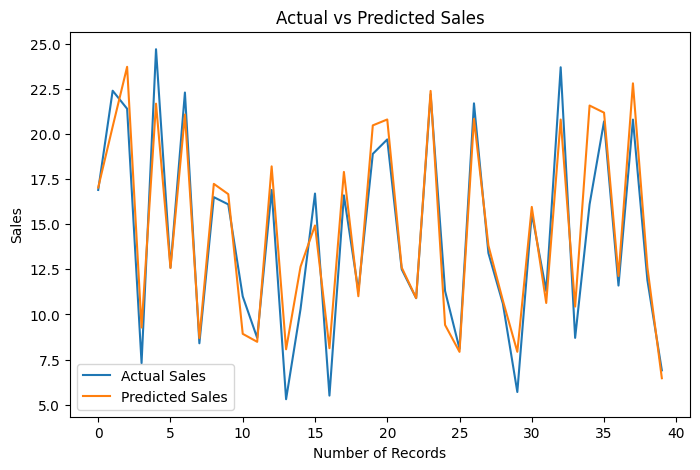

In [19]:
plt.figure(figsize=(8,5))

plt.plot(y_test.values, label='Actual Sales')

plt.plot(y_pred, label='Predicted Sales')

plt.title("Actual vs Predicted Sales")

plt.xlabel("Number of Records")

plt.ylabel("Sales")

plt.legend()

plt.show()

## Observation

The graph compares the actual sales values with the predicted sales values generated by the Multiple Linear Regression model. The predicted sales line closely follows the actual sales line, indicating that the model performs well in predicting sales.

Although there are slight variations between actual and predicted values at some points, the overall trend is very similar. This shows that the model has learned the relationship between advertising expenditure and sales effectively.

The visualization also supports the high R² score obtained during model evaluation, confirming that the model provides accurate and reliable sales predictions.

## Correlation Heatmap Analysis

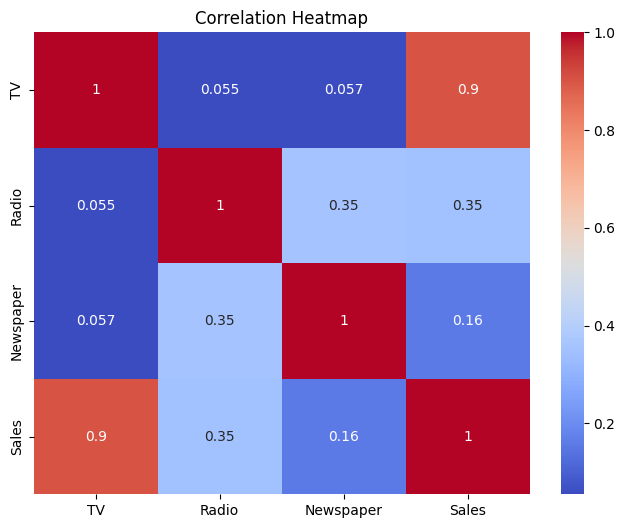

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(sales_data.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

## Observation

The correlation heatmap shows the relationship between advertising platforms and sales. TV advertising has the highest positive correlation with sales, indicating that it contributes the most to increasing product sales.

Radio advertising also shows a moderate positive correlation with sales, while Newspaper advertising has a comparatively weaker relationship.

The heatmap helps in understanding which features are more influential in predicting sales. Since TV and Radio have stronger correlations with sales, they play a significant role in improving the performance of the Multiple Linear Regression model.

## Pairplot Analysis

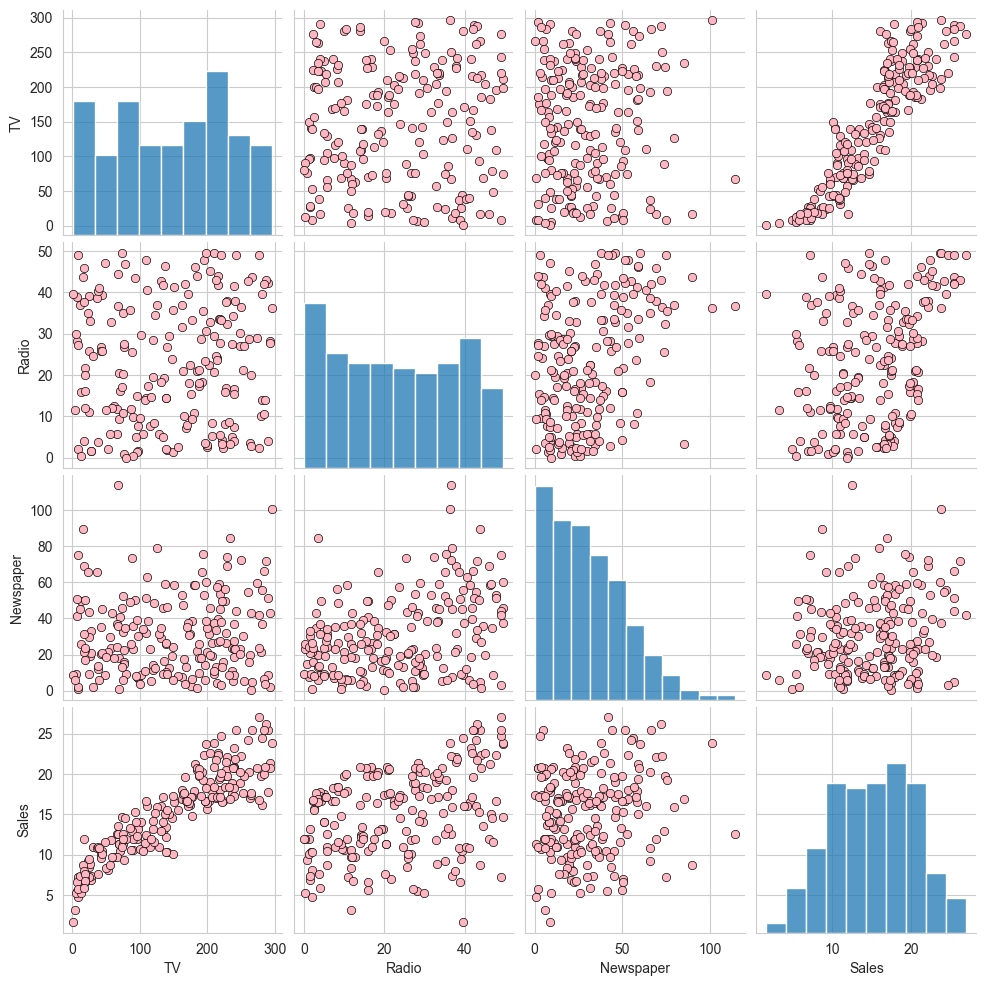

In [30]:
sns.set_style("whitegrid")

sns.pairplot(
    sales_data,
    plot_kws={
        'color': 'lightpink',
        'edgecolor': 'black'
    }
)

plt.show()

## Observation

The pairplot visualization shows the relationship between all variables in the dataset, including TV, Radio, Newspaper advertising, and Sales.

A strong positive linear relationship can be observed between TV advertising and Sales, indicating that higher TV advertising expenditure generally leads to increased sales. Radio advertising also shows a positive relationship with Sales, although it is slightly weaker compared to TV advertising.

Newspaper advertising displays a weaker correlation with Sales, suggesting that it has less influence on sales prediction.

The diagonal plots represent the distribution of each variable, helping to understand the spread and concentration of data values. Overall, the pairplot provides a clear visual understanding of feature relationships and supports the effectiveness of Multiple Linear Regression for this dataset.

## TV Advertising vs Sales Analysis

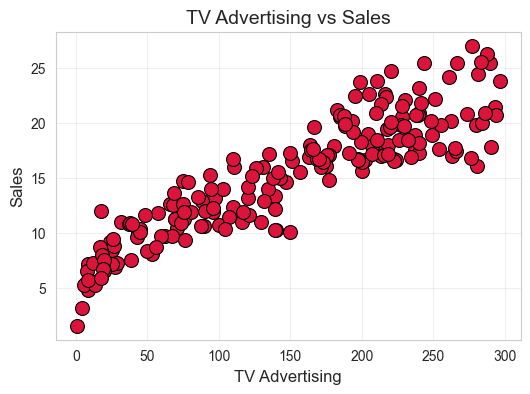

In [29]:
sns.set_style("whitegrid")

plt.figure(figsize=(6,4))

sns.scatterplot(
    x='TV',
    y='Sales',
    data=sales_data,
    color='crimson',
    s=100,
    edgecolor='black'
)

plt.title("TV Advertising vs Sales", fontsize=14)

plt.xlabel("TV Advertising", fontsize=12)

plt.ylabel("Sales", fontsize=12)

plt.grid(alpha=0.3)

plt.show()

## Observation

The scatter plot illustrates the relationship between TV advertising expenditure and product sales. A strong positive linear relationship can be observed, indicating that sales tend to increase as TV advertising spending increases.

Most data points follow an upward trend, which suggests that TV advertising is highly effective in influencing sales performance. The distribution of points also indicates that TV advertising has a stronger impact on sales compared to other advertising platforms.

This visualization supports the correlation analysis and confirms that TV advertising is one of the most important features for predicting sales using Multiple Linear Regression.

## Radio Advertising vs Sales Analysis

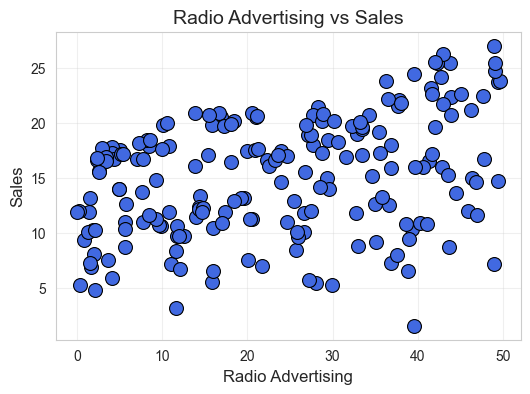

In [28]:
sns.set_style("whitegrid")

plt.figure(figsize=(6,4))

sns.scatterplot(
    x='Radio',
    y='Sales',
    data=sales_data,
    color='royalblue',
    s=100,
    edgecolor='black'
)

plt.title("Radio Advertising vs Sales", fontsize=14)

plt.xlabel("Radio Advertising", fontsize=12)

plt.ylabel("Sales", fontsize=12)

plt.grid(alpha=0.3)

plt.show()

## Observation

The scatter plot shows the relationship between Radio advertising expenditure and product sales. A positive correlation can be observed, indicating that sales generally increase as Radio advertising spending increases.

The data points form an upward trend, although the relationship is slightly less strong compared to TV advertising. This suggests that Radio advertising plays an important role in influencing sales but has a moderate impact when compared to TV advertisements.

Overall, the visualization indicates that Radio advertising contributes positively to sales prediction and is a useful feature in the Multiple Linear Regression model.

## Newspaper Advertising vs Sales Analysis

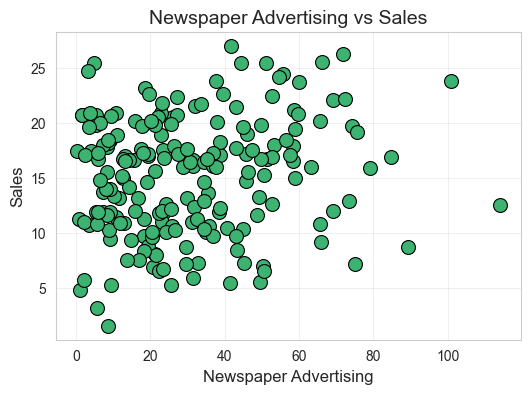

In [27]:
sns.set_style("whitegrid")

plt.figure(figsize=(6,4))

sns.scatterplot(
    x='Newspaper',
    y='Sales',
    data=sales_data,
    color='mediumseagreen',
    s=100,
    edgecolor='black'
)

plt.title("Newspaper Advertising vs Sales", fontsize=14)

plt.xlabel("Newspaper Advertising", fontsize=12)

plt.ylabel("Sales", fontsize=12)

plt.grid(alpha=0.3)

plt.show()

## Observation

The scatter plot represents the relationship between Newspaper advertising expenditure and product sales. A weak positive relationship can be observed between Newspaper advertising and Sales compared to TV and Radio advertising.

The data points are more scattered and less concentrated along a clear linear pattern, indicating that Newspaper advertising has a smaller influence on sales prediction.

Although Newspaper advertising contributes to sales to some extent, its impact is relatively lower than other advertising platforms. This suggests that Newspaper advertising is a less significant feature in the Multiple Linear Regression model for predicting sales.

# Visualization Insights

The visualizations provided valuable insights into the relationship between advertising expenditure and product sales. The correlation heatmap showed that TV advertising has the strongest positive correlation with sales, indicating that it plays the most significant role in increasing product sales. Radio advertising also demonstrated a positive relationship with sales, while Newspaper advertising showed a comparatively weaker correlation.

The scatter plots further confirmed these relationships by displaying upward trends between advertising expenditure and sales, especially in the case of TV advertising. This suggests that higher spending on TV advertisements generally leads to increased sales performance. Radio advertising also contributes positively to sales, although its impact is moderate compared to TV advertising. On the other hand, Newspaper advertising exhibited a weaker linear pattern, indicating a smaller influence on sales prediction.

The pairplot visualization helped in understanding both the distribution of variables and the relationships among all features in the dataset. The plots showed patterns that are suitable for applying Multiple Linear Regression. Additionally, the Actual vs Predicted Sales graph demonstrated that the predicted sales values closely follow the actual sales values, indicating that the model performs effectively and provides accurate predictions.

Overall, the visualizations confirmed that advertising expenditure significantly affects product sales and validated the effectiveness of Multiple Linear Regression for sales prediction.